In [1]:
using CairoMakie
using LaTeXStrings
using Printf
include("constants.jl")

In [2]:
N, q = 300, 100
osc(N, q) = factorial(big(q+N-1))/factorial(big(q))/factorial(big(N-1))

osc (generic function with 1 method)

In [3]:
1.0e22*k_B*(log(1.0e24)-log(1.0e22)+1)

0.7738772612114266

In [4]:
# f = Figure()


# ax = Axis(f[1, 1], xlabel = L"q_A", ylabel = L"\Omega_\text{total}", 
#     title = "Title",
#     xticks = 0:20:100,
#     ytickformat = values -> [@sprintf("%.1e", v) for v in values],
#     )

# lines!(ax, 0:1:100, )
# #xticks!(ax, 0:20:100)
# # ylims!(ax, -1.1*abs(ym), 1.5*abs(ym))

# f
# #save("schroeder_2_5.png", f)

In [5]:
function saktur_tetrode(N, V, U, m)
    return N*k_B *(log((V/N) *(4*π*m*U/3/N/(ħ*2*π)^2)^(3/2)) + 2.5)
end

function S_distinguishable(N, V, U, m)
    return saktur_tetrode(N, V, U, m) + N*k_B*log(N)
end

S_distinguishable (generic function with 1 method)

In [6]:
saktur_tetrode(N_A, 0.025, 3700, 4*m_p)  # He

126.24346191171611

In [7]:
saktur_tetrode(N_A, 0.025, 3700, 40*m_p)  # Ar

154.96059843293992

In [8]:
N_V = 101325/k_B/300

2.446313291792483e25

In [9]:
((ħ*2*π)^2/(π*(4*m_p)*k_B))*(N_V)^(2/3)*exp(-5/3)

0.024080844226095677

In [10]:
(ħ*2*π/(π*(4*m_p)*k_B))

2.2833111568505985e15

In [11]:
S_distinguishable(N_A, 0.025, 3700, 4*m_p)  # He

581.5010306480422

In [12]:
N_book = 1/(m_p*12.011)
S_book = N_book * k_B

687.2366809537417

In [13]:
N_moose = 300/(m_p*18)
S_moose = N_moose * k_B

137573.3295822565

In [14]:
N_sun = 2.0e30/m_p
S_sun = N_sun*k_B*2

3.3017599099741565e34

In [15]:
M_sun = 2.0e30

2.0e30

In [16]:
8*π^2*G*M_sun^2/(2*π*ħ * c)

1.061107034529068e77

In [17]:
1.0/(16*π^2*G*2.0e30*k_B/(c^2*ħ*2*π*c))

6.13477910229671e-8

In [18]:
homega = 1.60218e-21
T = 0.1:1:1000
C_V = @. (homega)^2/k_B/(T^2) * exp(-homega/(k_B*T))*N_A;

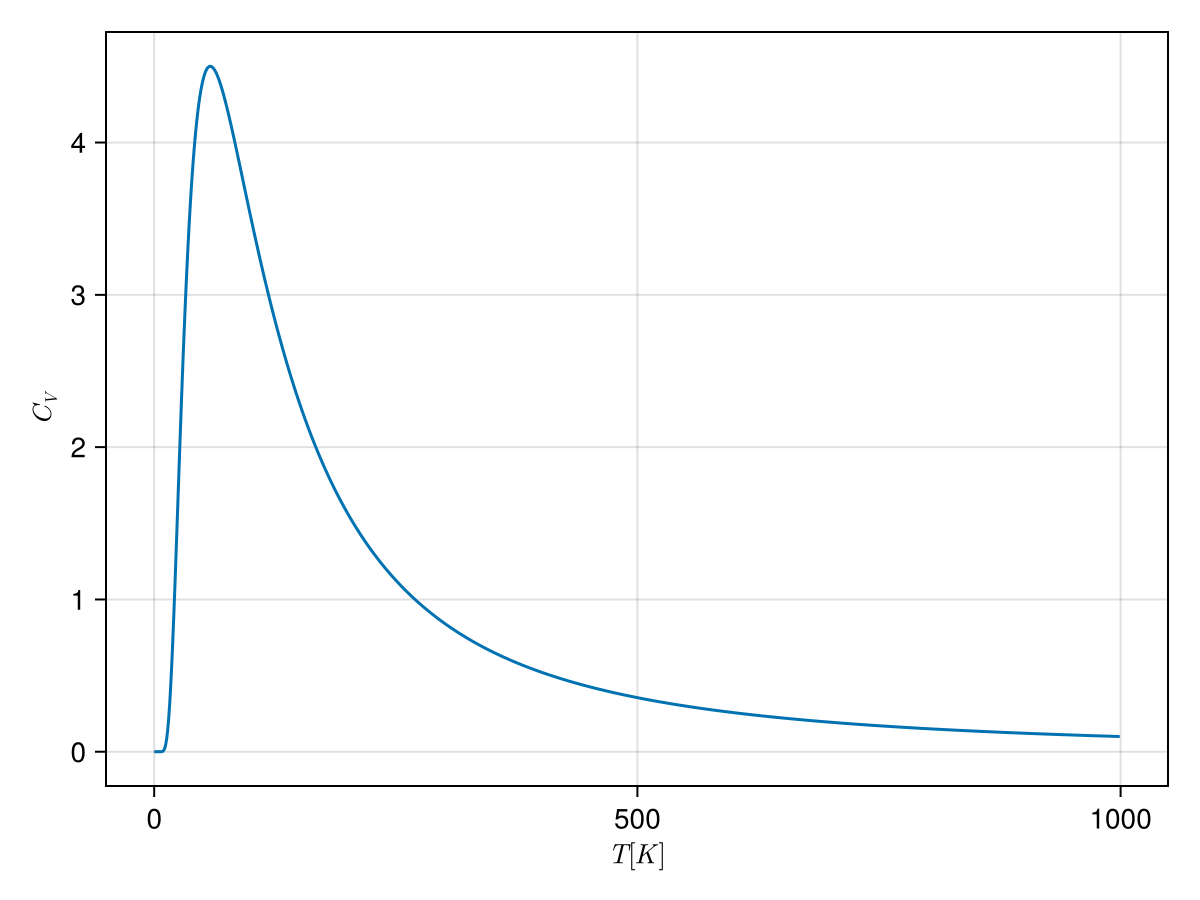

In [19]:
f = Figure()


ax = Axis(f[1, 1], xlabel = L"T [K]", ylabel = L"C_V", 
    # title = "Title",
    # xticks = 0:20:100,
    # ytickformat = values -> [@sprintf("%.1e", v) for v in values],
    )
lines!(ax, T, C_V)
f
#save("schroeder_prob_3_8.png", f)

In [20]:
homega/k_B/100

1.160454250138884

In [21]:
k_B

1.380649e-23

In [22]:
333/273*30

36.5934065934066

In [23]:
4.18*30*log((25+273)/273)

10.987760091583754

In [24]:
30*333/(25+273)

33.52348993288591

In [25]:
30*4.18*25/(25+273)

10.520134228187919

In [26]:
47.6-44.0

3.6000000000000014

In [27]:
C=4.18
C*50000*log((273+40)/(273+55)) + C*25000*log((273+40)/(273+10))

745.655278333661

In [28]:
1000*24*365*3600/300

1.0512e8

In [29]:
S_al(T) = 0.00135 * T + 1/3*2.48e-5*T^3

S_al (generic function with 1 method)

In [30]:
S_al(1)/k_B, S_al(10)/k_B

(9.837885419586488e19, 1.576553248991356e21)

In [31]:
(8*1024*1024*1024.0)*log(2)*k_B*300

2.4661520837839323e-11

In [32]:
8.0*(1024)^3

8.589934592e9

In [33]:
S=[log(factorial(big(100))) - log(factorial(big(n))) - log(factorial(big(100-n))) for n in 0:100];

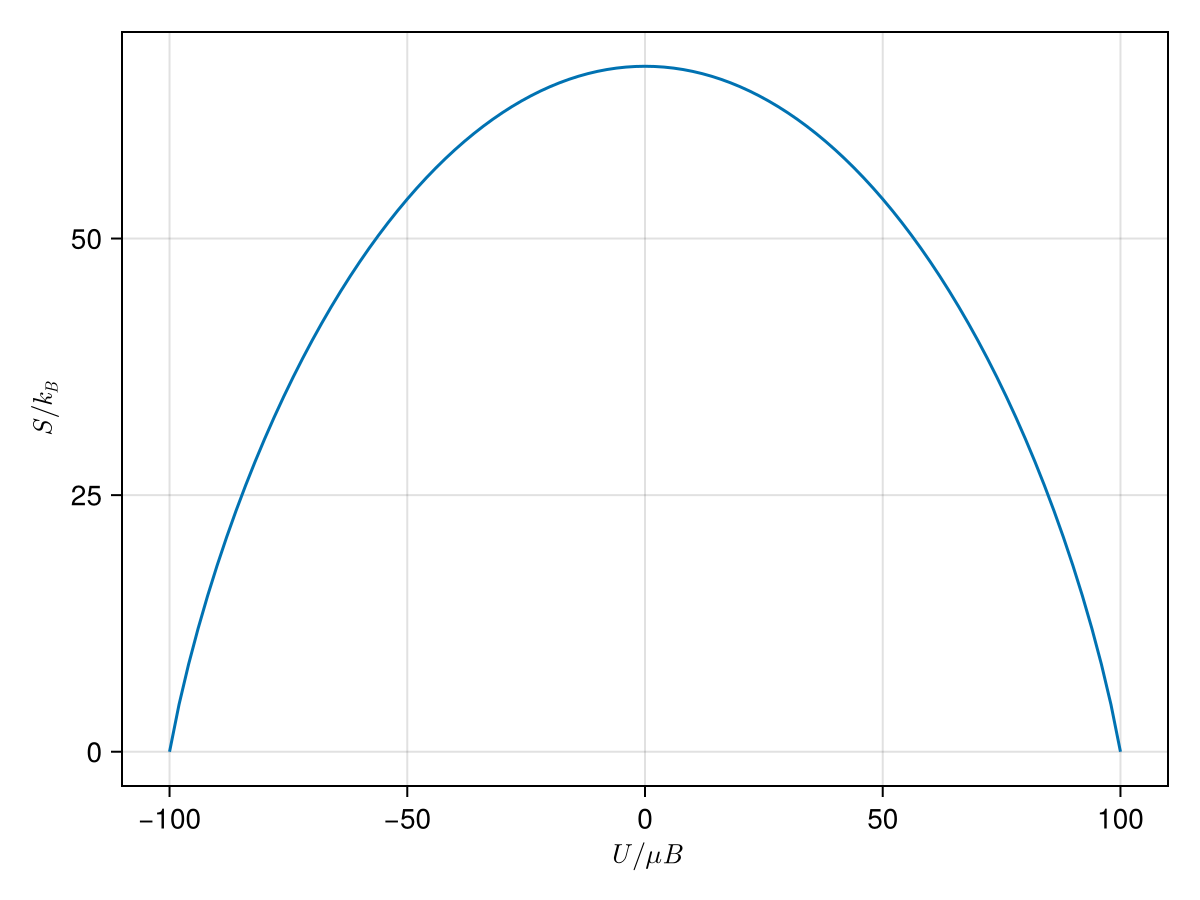

In [34]:
f = Figure()


ax = Axis(f[1, 1], xlabel = L"U/\mu B", ylabel = L"S/k_B", 
    # title = "Title",
    # xticks = 0:20:100,
    # ytickformat = values -> [@sprintf("%.1e", v) for v in values],
    )
lines!(ax, -100:2:100, S)
f
#save("schroeder_3_8.png", f)

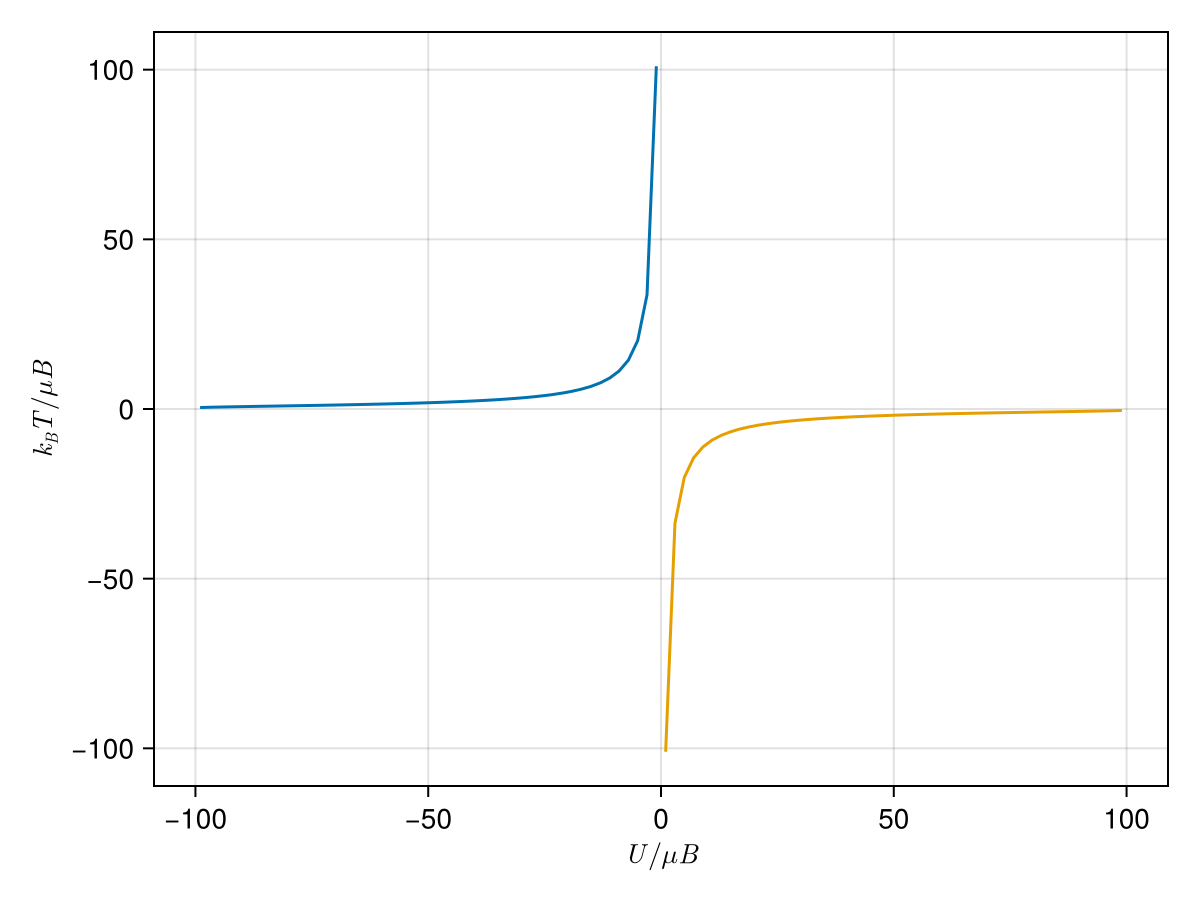

In [35]:
S1=[log(factorial(big(100))) - log(factorial(big(n))) - log(factorial(big(100-n))) for n in 0:100];
U0 = -100:2:100
U1 = 0.5*(U0[1:end-1] + U0[2:end])
ΔS1 = S1[2:end]-S1[1:end-1]
T=(2 ./ ΔS1)

f = Figure()


ax = Axis(f[1, 1], xlabel = L"U/\mu B", ylabel = L"k_BT/\mu B", 
    # title = "Title",
    # xticks = 0:20:100,
    # ytickformat = values -> [@sprintf("%.1e", v) for v in values],
    )
lines!(ax, U1[1:50], T[1:50])
lines!(ax, U1[51:100], T[51:100])
f
#save("schroeder_3_9.png", f)

In [36]:
length(ΔU1)

LoadError: UndefVarError: `ΔU1` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

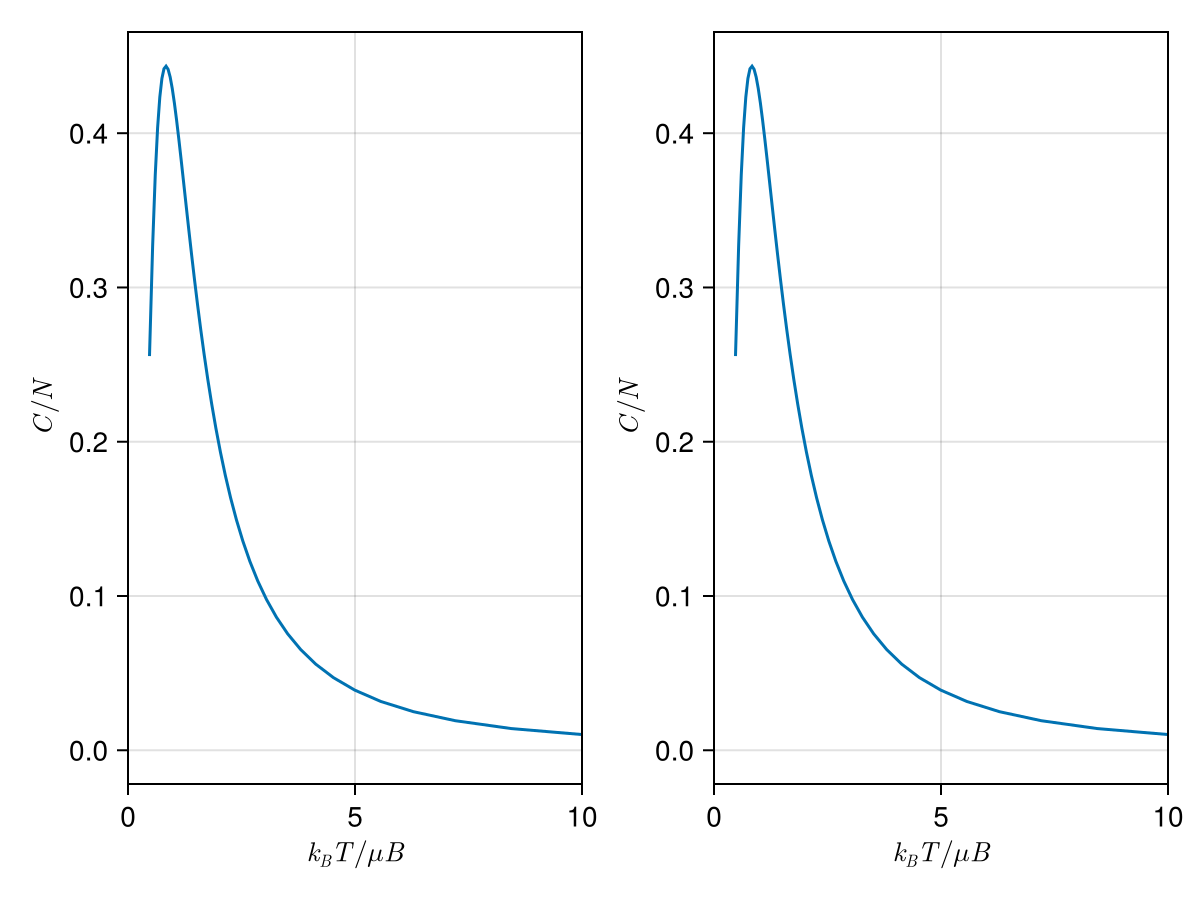

In [ ]:
ΔT1= T[2:50] - T[1:49]
ΔU1 = U1[2:50] - U1[1:49]
T2 = 0.5*(T[2:50] + T[1:49])
f = Figure()



ax1 = Axis(f[1, 1], xlabel = L"k_BT/\mu B", ylabel = L"C/N", 
    # title = "Title",
    # xticks = 0:20:100,
    # ytickformat = values -> [@sprintf("%.1e", v) for v in values],
    )
xlims!(ax1, 0,10)
lines!(ax1, T2, ΔU1./ΔT1/100)

ax2 = Axis(f[1, 2], xlabel = L"k_BT/\mu B", ylabel = L"C/N", 
    # title = "Title",
    # xticks = 0:20:100,
    # ytickformat = values -> [@sprintf("%.1e", v) for v in values],
    )
xlims!(ax2, 0,10)
lines!(ax2, T1, ΔU1./ΔT1/100)



f
# #save("schroeder_3_9.png", f)

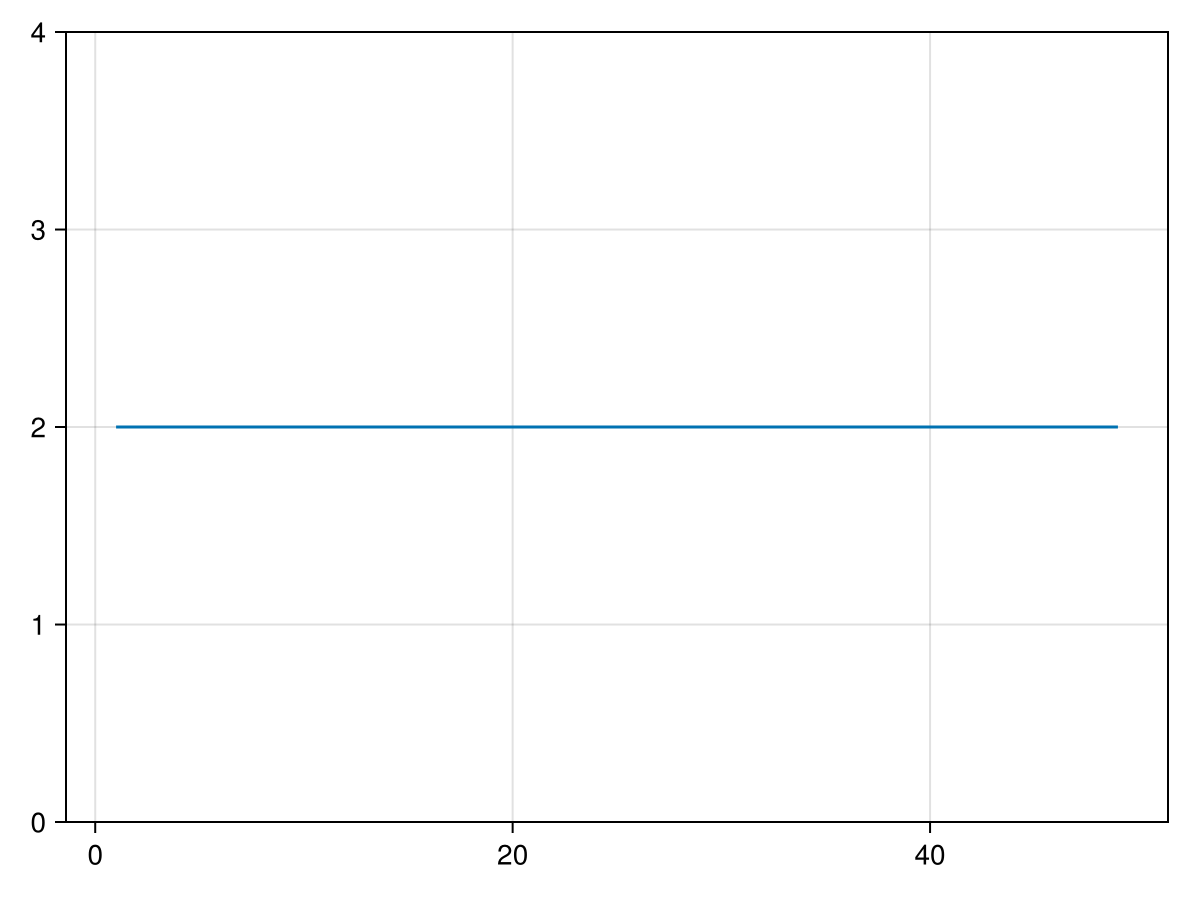

In [ ]:
lines(ΔU1)

In [40]:
tanh(μ_B * 2.06/k_B/2.2)

0.557341459995613

In [41]:
μ_B * 2.06/k_B/2.2

0.628968385684756

In [42]:
0.5*(1+0.557)

0.7785

In [47]:
N=100;Nup=0.7789*N
(N*log(N)-Nup*log(Nup)-(N-Nup)*log(N-Nup))/(N*log(2))

0.7621709902668578

In [53]:
atanh(0.99)

2.6466524123622457

In [52]:
2.2/4.208

0.5228136882129277